# Classification Project

### 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('car-crash-severity-prediction/car_crash_train.csv')
print(f"Shape: {df.shape}")


Shape: (4000, 19)


In [3]:
df.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [4]:
df.info()

print("\n\nNumerical columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

19 columns (18 features + 1 target 'Severity'):
- 6 numerical: Crash Speed, Impact Angle, Vehicle Age, Driver Age, Driver Experience, Alcohol Level (BAC%), Visibility Distance
- 12 categorical: Airbag Deployed, Seatbelt Used, Weather/Road Conditions, Crash Type, Vehicle Type, Brake/Tire Condition, Distraction Level, Time of Day, Traffic Density
- Target (multi-class): Severity → [Minor Injury, Severe Injury, Fatal]

                   Missing Count  Missing %
Distraction Level           2360       59.0


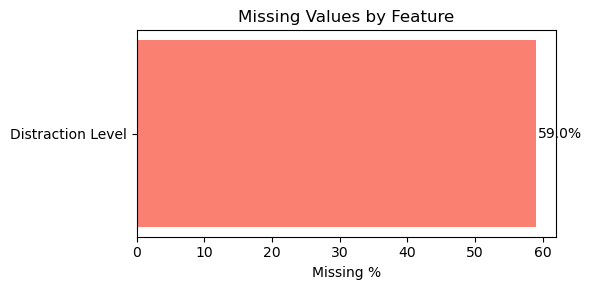

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print(missing_df)

# Visual
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(missing_df.index, missing_df['Missing %'], color='salmon')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.3, i, f"{v}%", va='center')
plt.tight_layout()
plt.show()

Only 'Distraction Level' has missing values, 2360 out of 4000 rows (59%).
This is NOT random missingness. The likely interpretation is that when no distraction
was recorded, the driver was simply NOT distracted. This is "Missing Not At Random" (MNAR).
We will treat NaN as its own category: "None" during preprocessing.

               Count      %
Severity                   
Minor Injury    2756  68.90
Severe Injury   1038  25.95
Fatal            206   5.15


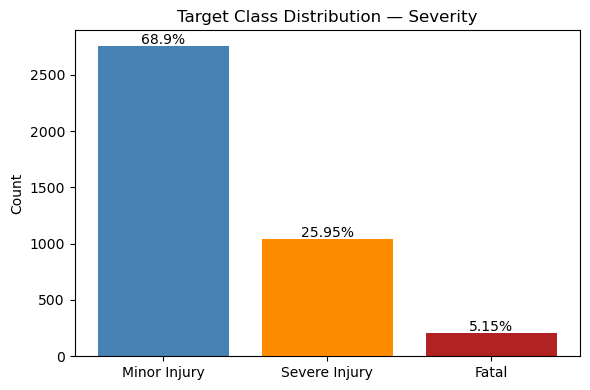

In [6]:
target_counts = df['Severity'].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)

print(pd.DataFrame({'Count': target_counts, '%': target_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_counts.index, target_counts.values,
              color=['steelblue', 'darkorange', 'firebrick'])
ax.set_title('Target Class Distribution — Severity')
ax.set_ylabel('Count')
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{pct}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

The target is imbalanced:
- Minor Injury:  68.9%
- Severe Injury: 25.95%
- Fatal:          5.15%

This class imbalance is important to keep in mind during modelling.
Algorithms like Naïve Bayes and Logistic Regression are sensitive to it.
We will use stratified train/test splits and consider class_weight='balanced'
where supported.

In [7]:
num_cols = df.select_dtypes(include='number').columns.tolist()

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(3)
desc['kurtosis'] = df[num_cols].kurt().round(3)
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)  # Coefficient of Variation

desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,CV (%)
Crash Speed (km/h),4000.0,111.000,52.228,20.0,66.000,112.000,157.000,199.0,-0.047,-1.218,47.05
Impact Angle (degrees),4000.0,89.980,51.302,0.0,45.000,89.500,134.000,179.0,-0.010,-1.174,57.01
Vehicle Age (years),4000.0,9.446,5.718,0.0,5.000,9.000,14.000,19.0,0.028,-1.195,60.54
Driver Age,4000.0,48.699,17.816,18.0,34.000,49.000,64.000,79.0,-0.021,-1.199,36.58
Driver Experience (years),4000.0,24.723,14.212,0.0,13.000,25.000,37.000,49.0,-0.024,-1.168,57.48
Alcohol Level (BAC%),4000.0,0.101,0.058,0.0,0.051,0.102,0.152,0.2,-0.033,-1.230,57.13
Visibility Distance (m),4000.0,247.584,143.478,10.0,120.000,244.000,372.000,499.0,0.070,-1.209,57.95


Key observations:
- Crash Speed:  ranges 20–220 km/h, mean ~112. High CV → high variability.
- Alcohol BAC%: mean ~0.079, highly right-skewed → most drivers near sober, some very high.
- Driver Age:   ranges 18–80, fairly uniform.
- Visibility:   wide range 10–500m, relevant for crash severity.
- Vehicle Age:  0–25 years.

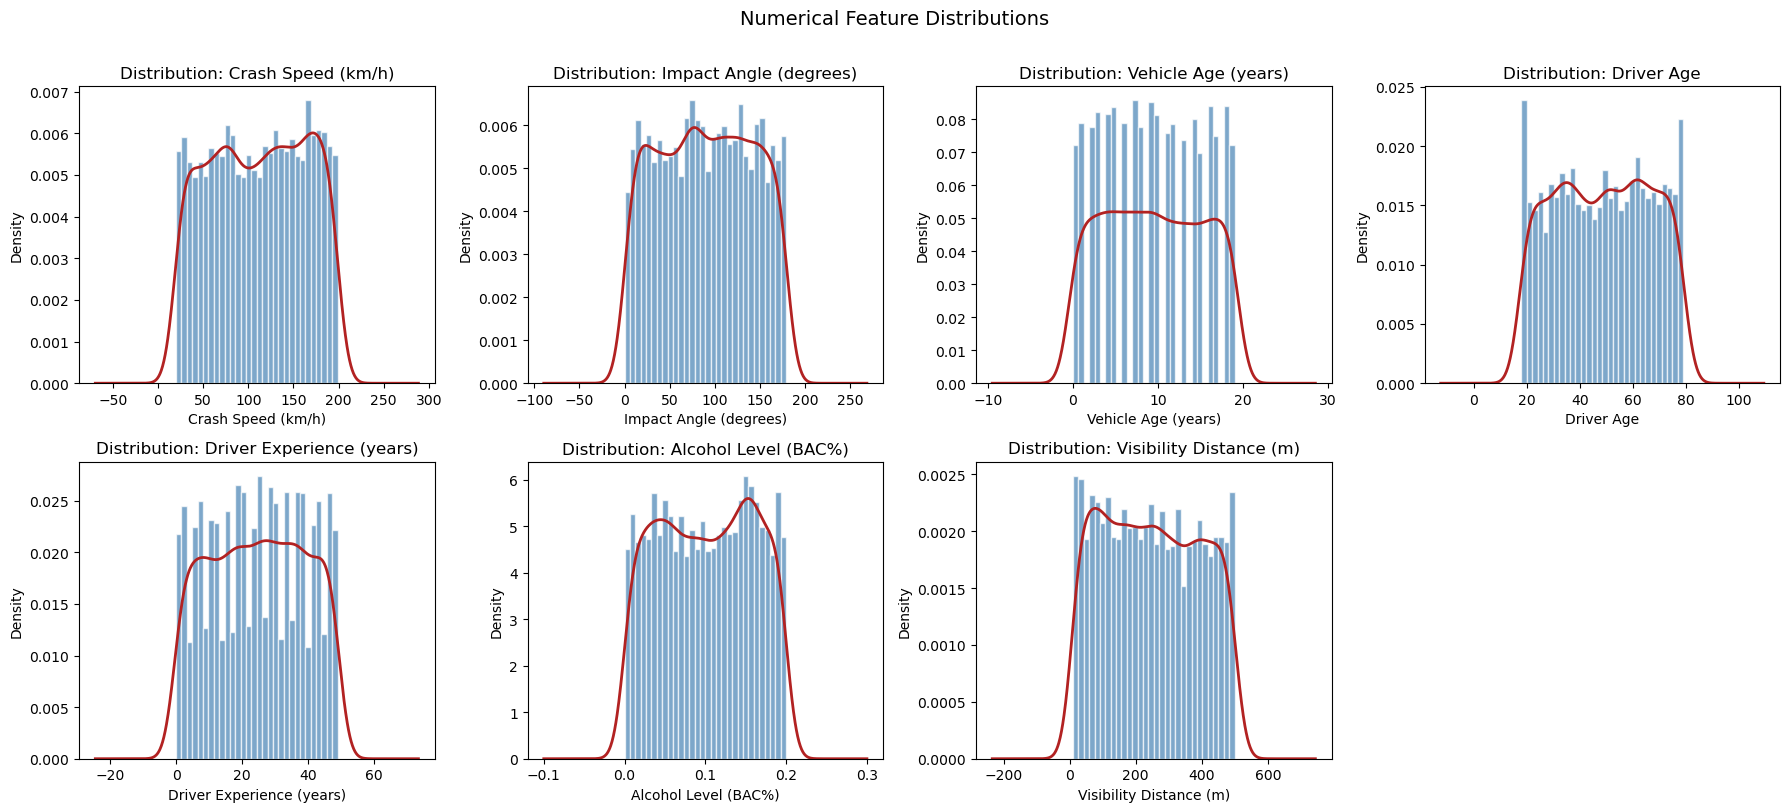

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.7, density=True)
    df[col].plot(kind='kde', ax=axes[i], color='firebrick', linewidth=2)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
cat_cols = df.select_dtypes(include='object').columns.drop('Severity').tolist()

print("Categorical Feature Summary:")
print("="*55)
for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    print(f"\n{col} ({df[col].nunique(dropna=False)} unique):")
    print(vc.to_string())

Categorical Feature Summary:

Airbag Deployed (2 unique):
Airbag Deployed
Yes    2817
No     1183

Seatbelt Used (2 unique):
Seatbelt Used
Yes    3174
No      826

Weather Conditions (4 unique):
Weather Conditions
Clear    2345
Rain      846
Snow      421
Fog       388

Road Conditions (4 unique):
Road Conditions
Dry       2792
Wet        603
Icy        395
Uneven     210

Crash Type (4 unique):
Crash Type
Side impact    1413
Rear-end       1175
Head-on        1020
Rollover        392

Vehicle Type (4 unique):
Vehicle Type
Sedan         1644
SUV           1207
Truck          751
Motorcycle     398

Brake Condition (2 unique):
Brake Condition
Good        3369
Worn out     631

Tire Condition (2 unique):
Tire Condition
Good        3225
Worn out     775

Distraction Level (4 unique):
Distraction Level
NaN           2360
Phone          773
Drowsiness     439
Other          428

Time of Day (3 unique):
Time of Day
Afternoon    1579
Morning      1223
Night        1198

Traffic Density (3 uni

In [10]:
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

print(f"{'Feature':<30} {'Lower Fence':>12} {'Upper Fence':>12} {'Outlier Count':>14} {'Outlier %':>10}")
print("="*82)
for col in num_cols:
    outliers, lower, upper = detect_outliers(df[col])
    pct = round(len(outliers) / len(df) * 100, 2)
    print(f"{col:<30} {lower:>12.3f} {upper:>12.3f} {len(outliers):>14} {pct:>9.2f}%")

Feature                         Lower Fence  Upper Fence  Outlier Count  Outlier %
Crash Speed (km/h)                  -70.500      293.500              0      0.00%
Impact Angle (degrees)              -88.500      267.500              0      0.00%
Vehicle Age (years)                  -8.500       27.500              0      0.00%
Driver Age                          -11.000      109.000              0      0.00%
Driver Experience (years)           -23.000       73.000              0      0.00%
Alcohol Level (BAC%)                 -0.101        0.304              0      0.00%
Visibility Distance (m)            -258.000      750.000              0      0.00%


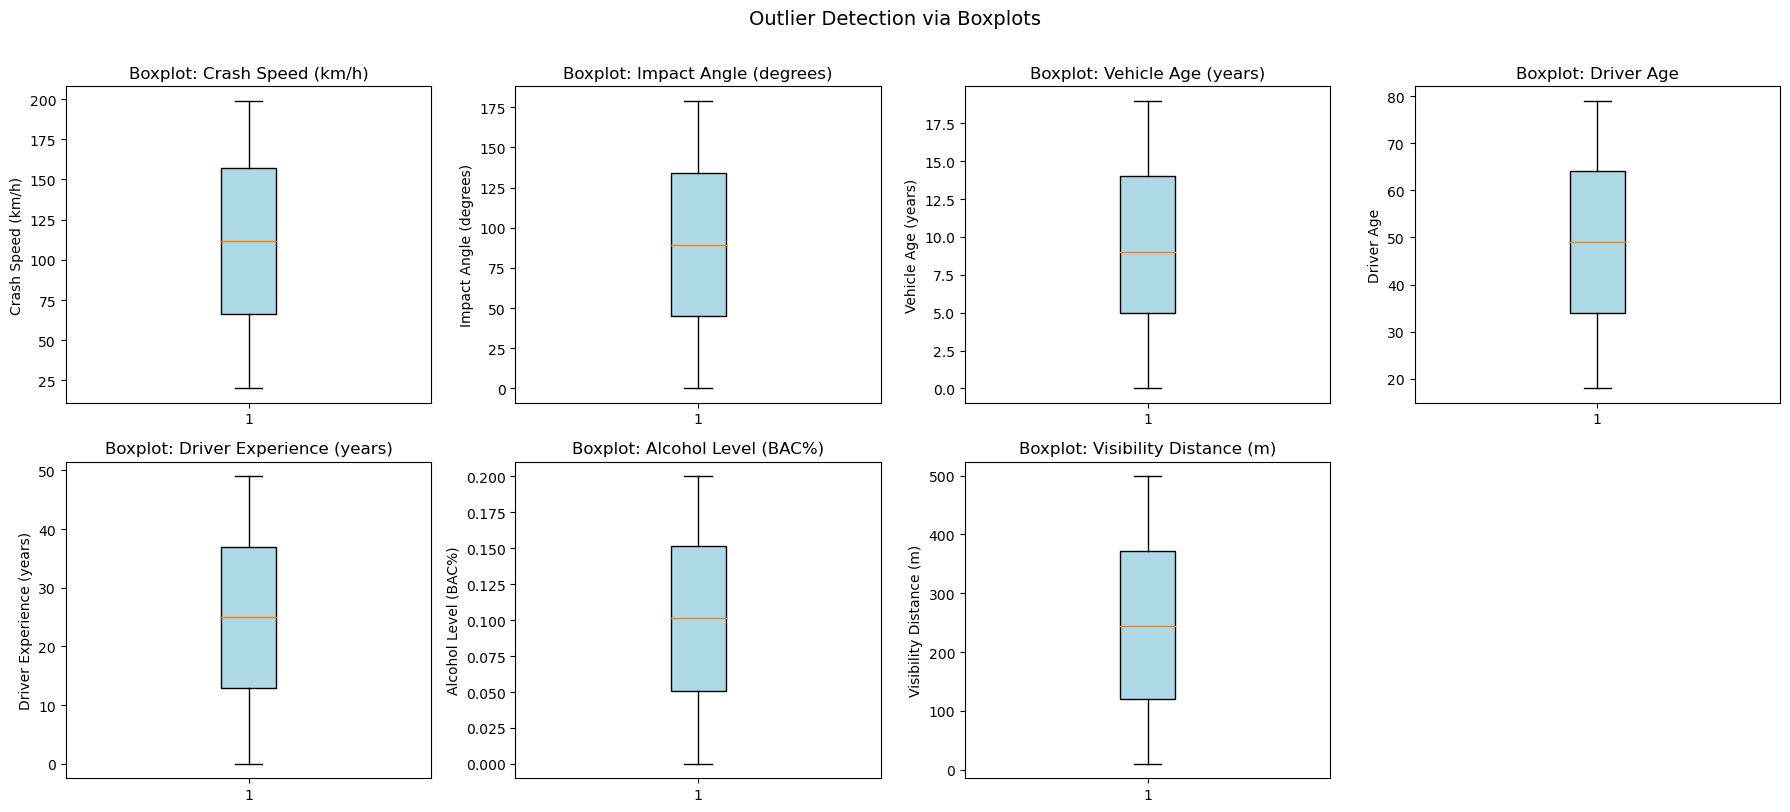

In [11]:
# Boxplots for visual outlier inspection
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [12]:
range_df = pd.DataFrame({
    'Min':    df[num_cols].min(),
    'Max':    df[num_cols].max(),
    'Range':  df[num_cols].max() - df[num_cols].min(),
    'Mean':   df[num_cols].mean().round(3),
    'Std':    df[num_cols].std().round(3),
    'Skew':   df[num_cols].skew().round(3)
})
range_df

,Min,Max,Range,Mean,Std,Skew
Crash Speed (km/h),20.000000,199.000000,179.000000,111.000,52.228,-0.047
Impact Angle (degrees),0.000000,179.000000,179.000000,89.980,51.302,-0.010
Vehicle Age (years),0.000000,19.000000,19.000000,9.446,5.718,0.028
Driver Age,18.000000,79.000000,61.000000,48.699,17.816,-0.021
Driver Experience (years),0.000000,49.000000,49.000000,24.723,14.212,-0.024
Alcohol Level (BAC%),0.000054,0.199936,0.199882,0.101,0.058,-0.033
Visibility Distance (m),10.000000,499.000000,489.000000,247.584,143.478,0.070


Range summary informs scaling strategy:
- Crash Speed (20–220), Visibility (10–500), Driver Age (18–80) → large ranges on different scales
  → requires StandardScaler or MinMaxScaler before KNN, Logistic Regression, Naïve Bayes
- Alcohol Level (BAC%) → very small scale (0–~0.3) but skewed → StandardScaler handles this
- Tree-based models (Decision Tree, Random Forest) are scale-invariant → no scaling needed for them
  but we will scale the full dataset for uniformity and use pipelines per model.

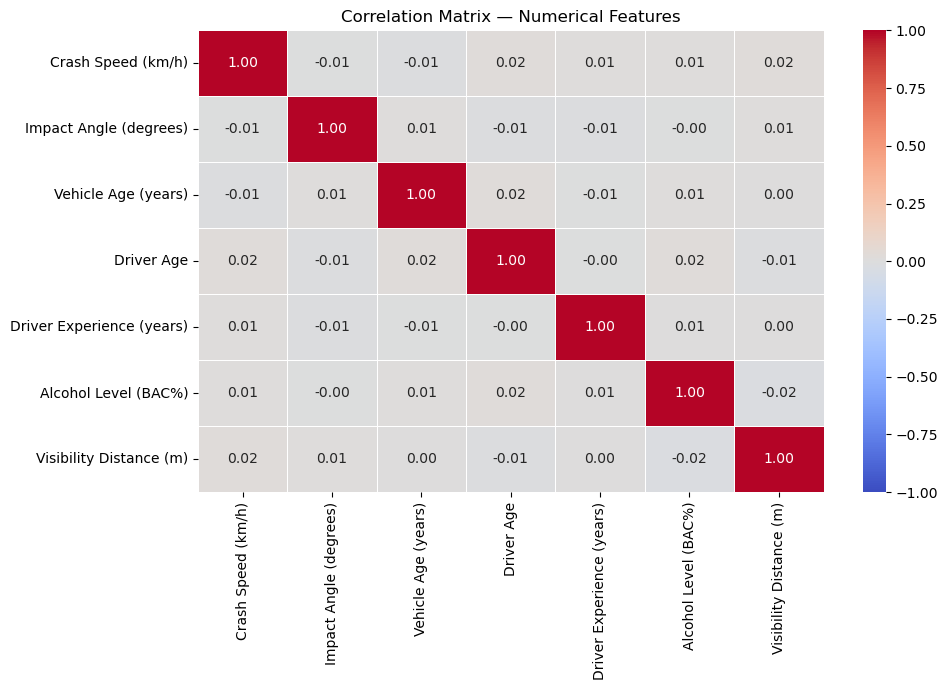

In [13]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

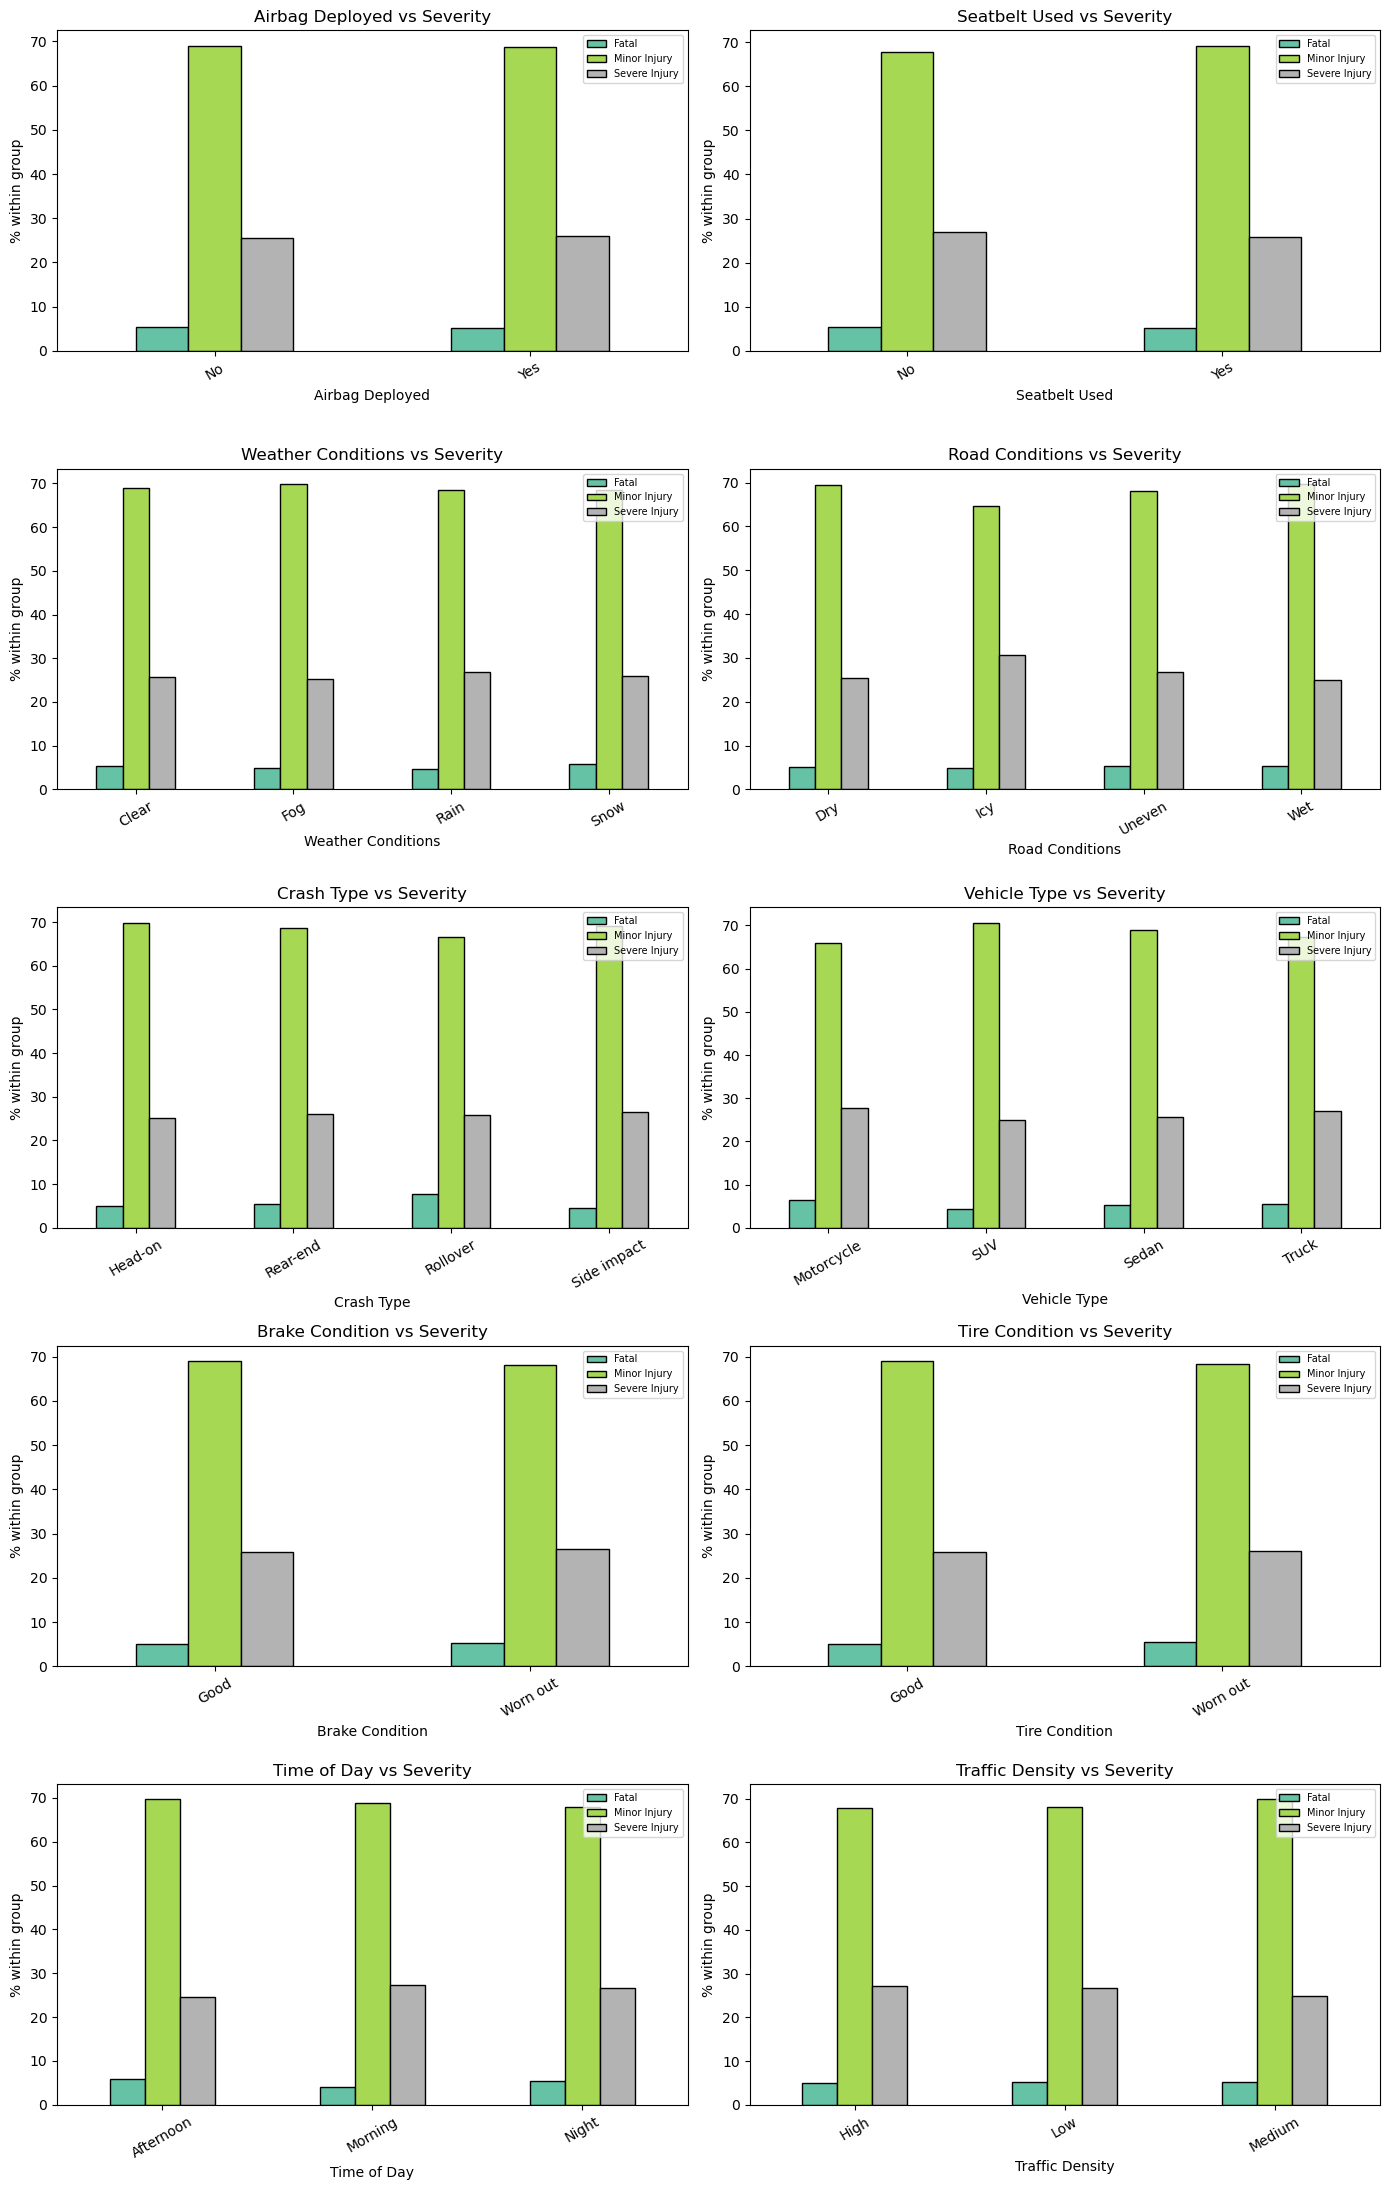

In [14]:
cat_cols = ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
            'Road Conditions', 'Crash Type', 'Vehicle Type',
            'Brake Condition', 'Tire Condition', 'Time of Day', 'Traffic Density']

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Severity'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(f'{col} vs Severity')
    axes[i].set_ylabel('% within group')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

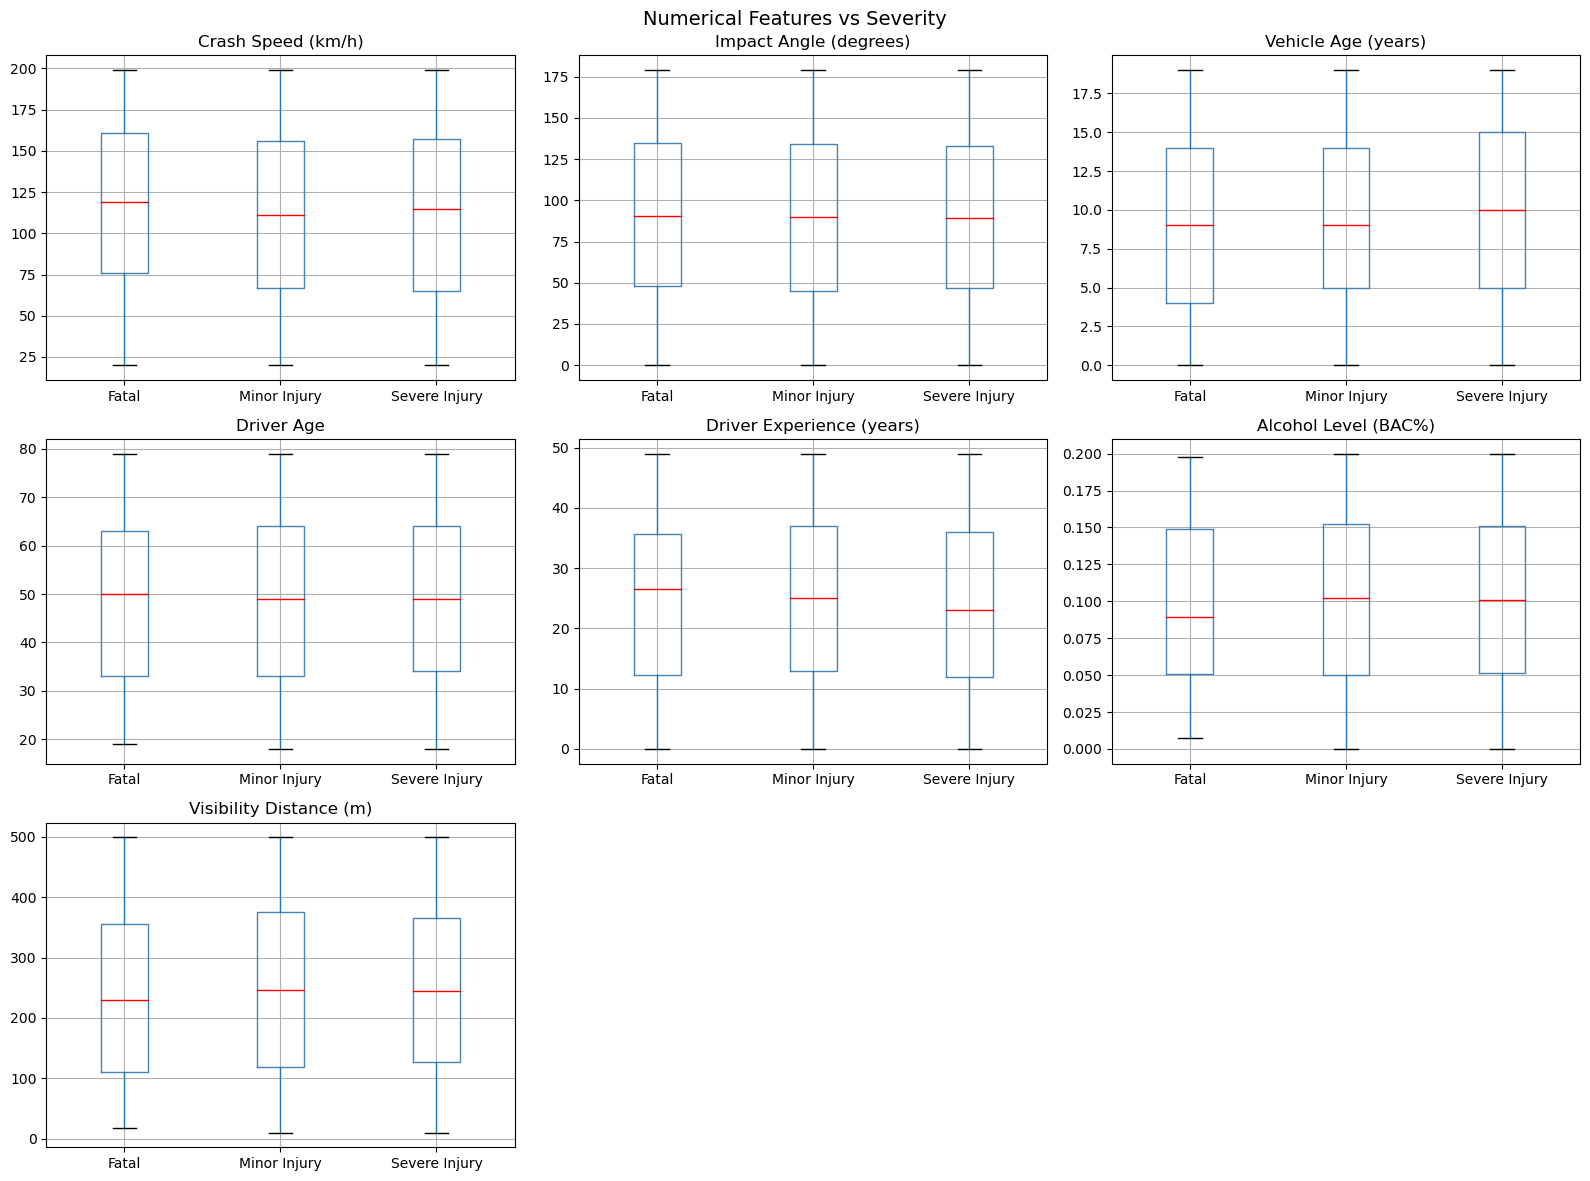

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Severity', ax=axes[i], 
               boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hide unused subplots if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Severity', fontsize=14)
plt.tight_layout()
plt.show()

**2. Preprocessing**

In [22]:
from scipy import stats

missing_mask = df['Distraction Level'].isnull()
df['is_missing'] = missing_mask.astype(int)

num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
            'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']

cat_cols = ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions',
            'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition',
            'Time of Day', 'Traffic Density', 'Severity']

# --- T-tests: numerical features vs missingness ---
print("=== T-TESTS: Numerical Features vs Missingness ===")
print(f"{'Feature':<32} {'Missing Mean':>14} {'NotMiss Mean':>14} {'p-value':>10} {'Sig':>5}")
print("="*80)
for col in num_cols:
    miss_vals   = df.loc[missing_mask, col].dropna()
    notmiss_vals = df.loc[~missing_mask, col].dropna()
    t, p = stats.ttest_ind(miss_vals, notmiss_vals)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{col:<32} {miss_vals.mean():>14.4f} {notmiss_vals.mean():>14.4f} {p:>10.6f} {sig:>5}")

# --- Chi-square tests: categorical features vs missingness ---
print("\n=== CHI-SQUARE TESTS: Categorical Features vs Missingness ===")
print(f"{'Feature':<25} {'Chi2':>10} {'p-value':>12} {'Sig':>5}")
print("="*55)
for col in cat_cols:
    ct = pd.crosstab(df[col], df['is_missing'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{col:<25} {chi2:>10.4f} {p:>12.6f} {sig:>5}")

df.drop(columns='is_missing', inplace=True)

=== T-TESTS: Numerical Features vs Missingness ===
Feature                            Missing Mean   NotMiss Mean    p-value   Sig
Crash Speed (km/h)                     110.8081       111.2756   0.780689    ns
Impact Angle (degrees)                  89.9903        89.9646   0.987608    ns
Vehicle Age (years)                      9.4008         9.5098   0.553612    ns
Driver Age                              48.5174        48.9598   0.439952    ns
Driver Experience (years)               25.1042        24.1744   0.041815     *
Alcohol Level (BAC%)                     0.1012         0.1013   0.938076    ns
Visibility Distance (m)                246.1720       249.6146   0.455518    ns

=== CHI-SQUARE TESTS: Categorical Features vs Missingness ===
Feature                         Chi2      p-value   Sig
Airbag Deployed               0.0303     0.861874    ns
Seatbelt Used                 1.3890     0.238573    ns
Weather Conditions            3.9649     0.265283    ns
Road Conditions       

**MNAR Conclusion**

Statistical tests (independent t-tests for numerical, chi-square for categorical)
were run to check whether missingness in 'Distraction Level' is associated with
any other observed feature.

Results:
- Every categorical feature: p >> 0.05 (all "ns" — not significant)
- Every numerical feature: p >> 0.05, with the single weak exception of
  Driver Experience (p=0.04, barely significant and likely a false positive
  at this sample size with no correction applied)

Interpretation:
The missingness in 'Distraction Level' CANNOT be explained by any other variable
in the dataset. This rules out:
  - MCAR (Missing Completely At Random), we can't confirm randomness was
    by design; the data was observed, not randomised
  - MAR (Missing At Random), MAR means missingness IS explainable by other
    observed columns. The tests show it is NOT.

This leaves MNAR (Missing Not At Random) as the only valid conclusion:
the missingness is related to the value of the variable itself, when
a driver was NOT distracted, there was simply nothing to record. The absence
of a value IS the information. This justifies filling NaN with "None"
(No Distraction) rather than imputing with mode or a statistical estimate.

In [23]:
from sklearn.model_selection import train_test_split

# Separate features and target BEFORE any fitting
X_raw = df.drop(columns='Severity')
y_raw = df['Severity'].map({'Minor Injury': 0, 'Severe Injury': 1, 'Fatal': 2})

# Stratified split preserves the 69/26/5 class ratios in both folds
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    stratify=y_raw,
    random_state=42
)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train : {X_train_raw.shape[0]} rows")
print(f"Test  : {X_test_raw.shape[0]} rows  (20% hold-out)")
print("\nTrain class distribution:")
print(y_train.value_counts().rename({0:'Minor Injury', 1:'Severe Injury', 2:'Fatal'}))
print("\nTest class distribution:")
print(y_test.value_counts().rename({0:'Minor Injury', 1:'Severe Injury', 2:'Fatal'}))

Train : 3200 rows
Test  : 800 rows  (20% hold-out)

Train class distribution:
Severity
Minor Injury     2205
Severe Injury     830
Fatal             165
Name: count, dtype: int64

Test class distribution:
Severity
Minor Injury     551
Severe Injury    208
Fatal             41
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ── Step 1: Impute Distraction Level (MNAR → "None") ─────────────────────────
X_train_proc = X_train_raw.copy().reset_index(drop=True)
X_test_proc  = X_test_raw.copy().reset_index(drop=True)

X_train_proc['Distraction Level'] = X_train_proc['Distraction Level'].fillna('None')
X_test_proc['Distraction Level']  = X_test_proc['Distraction Level'].fillna('None')

# ── Step 2: Binary encoding ───────────────────────────────────────────────────
# Binary Yes/No columns are mapped directly to 0/1.
# Label encoding is sufficient here — one-hot would double these columns for
# no benefit since they carry no ordinal ambiguity.

binary_maps = {
    'Airbag Deployed': {'Yes': 1, 'No': 0},
    'Seatbelt Used':   {'Yes': 1, 'No': 0},
    'Brake Condition': {'Good': 1, 'Worn out': 0},
    'Tire Condition':  {'Good': 1, 'Worn out': 0},
}
for col, mapping in binary_maps.items():
    X_train_proc[col] = X_train_proc[col].map(mapping)
    X_test_proc[col]  = X_test_proc[col].map(mapping)

print("Binary columns encoded.")

# ── Step 3: Ordinal encoding ──────────────────────────────────────────────────
# Traffic Density (Low < Medium < High) and Distraction Level have a natural
# severity ordering. OrdinalEncoder is fit ONLY on train, then applied to test.

ordinal_cfg = {
    'Traffic Density':   [['Low', 'Medium', 'High']],
    'Distraction Level': [['None', 'Other', 'Drowsiness', 'Phone']],
}
fitted_ordinal_encoders = {}
for col, categories in ordinal_cfg.items():
    enc = OrdinalEncoder(categories=categories)
    X_train_proc[col] = enc.fit_transform(X_train_proc[[col]])
    X_test_proc[col]  = enc.transform(X_test_proc[[col]])
    fitted_ordinal_encoders[col] = enc

print("Ordinal columns encoded.")

# ── Step 4: One-hot encoding ──────────────────────────────────────────────────
# Nominal columns have no natural order. Using integer labels would impose a
# false ordinal relationship (e.g. Rain=2 > Fog=1 numerically). One-hot treats
# each category as independent. We encode train and test together via reindex
# so both always have the exact same columns in the same order.

nominal_cols = ['Weather Conditions', 'Road Conditions', 'Crash Type',
                'Vehicle Type', 'Time of Day']

X_train_proc = pd.get_dummies(X_train_proc, columns=nominal_cols, drop_first=False, dtype=int)
X_test_proc  = pd.get_dummies(X_test_proc,  columns=nominal_cols, drop_first=False, dtype=int)

# Align: test may be missing a rare category that appeared in train → fill 0
train_feature_cols = X_train_proc.columns.tolist()
X_test_proc = X_test_proc.reindex(columns=train_feature_cols, fill_value=0)

print("Nominal columns one-hot encoded.")
print(f"\nShape after encoding — Train: {X_train_proc.shape} | Test: {X_test_proc.shape}")
print(f"Columns match: {list(X_train_proc.columns) == list(X_test_proc.columns)}")

# ── Step 5: StandardScaler ────────────────────────────────────────────────────
# KNN is distance-based — Crash Speed (20–220) would dominate BAC (0–0.3)
# without scaling. LR converges faster with scaled inputs. NB variance
# estimates are more meaningful when features are on the same scale.
# Tree models are scale-invariant but applying scaling consistently
# simplifies the pipeline (it won't hurt them).
# CRITICAL: fit ONLY on X_train_proc, then transform both.

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_proc),
    columns=train_feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_proc),
    columns=train_feature_cols
)

print("\nScaling complete.")
print(f"Any NaN in train scaled: {X_train_scaled.isnull().sum().sum()}")
print(f"Any NaN in test scaled : {X_test_scaled.isnull().sum().sum()}")

# ── Convenience aliases ───────────────────────────────────────────────────────
# Unscaled versions for tree-based models (scale-invariant)
X_train = X_train_proc
X_test  = X_test_proc

Binary columns encoded.
Ordinal columns encoded.
Nominal columns one-hot encoded.

Shape after encoding — Train: (3200, 32) | Test: (800, 32)
Columns match: True

Scaling complete.
Any NaN in train scaled: 0
Any NaN in test scaled : 0


In [25]:
from collections import Counter

print("Final preprocessed dataset summary")
print("="*50)
print(f"Total features : {X_train.shape[1]}")
print(f"Train samples  : {len(y_train)}  |  Test samples: {len(y_test)}")

label_map = {0: 'Minor Injury', 1: 'Severe Injury', 2: 'Fatal'}

print("\nTrain class balance:")
for k, v in sorted(Counter(y_train).items()):
    print(f"  {label_map[k]}: {v} ({v/len(y_train)*100:.1f}%)")

print("\nTest class balance:")
for k, v in sorted(Counter(y_test).items()):
    print(f"  {label_map[k]}: {v} ({v/len(y_test)*100:.1f}%)")

print(f"\nAny remaining NaN — train: {X_train.isnull().sum().sum()} | test: {X_test.isnull().sum().sum()}")
print(f"\nFeature list ({X_train.shape[1]} total):")
for col in X_train.columns:
    print(f"  - {col}")

Final preprocessed dataset summary
Total features : 32
Train samples  : 3200  |  Test samples: 800

Train class balance:
  Minor Injury: 2205 (68.9%)
  Severe Injury: 830 (25.9%)
  Fatal: 165 (5.2%)

Test class balance:
  Minor Injury: 551 (68.9%)
  Severe Injury: 208 (26.0%)
  Fatal: 41 (5.1%)

Any remaining NaN — train: 0 | test: 0

Feature list (32 total):
  - Crash Speed (km/h)
  - Impact Angle (degrees)
  - Airbag Deployed
  - Seatbelt Used
  - Vehicle Age (years)
  - Brake Condition
  - Tire Condition
  - Driver Age
  - Driver Experience (years)
  - Alcohol Level (BAC%)
  - Distraction Level
  - Traffic Density
  - Visibility Distance (m)
  - Weather Conditions_Clear
  - Weather Conditions_Fog
  - Weather Conditions_Rain
  - Weather Conditions_Snow
  - Road Conditions_Dry
  - Road Conditions_Icy
  - Road Conditions_Uneven
  - Road Conditions_Wet
  - Crash Type_Head-on
  - Crash Type_Rear-end
  - Crash Type_Rollover
  - Crash Type_Side impact
  - Vehicle Type_Motorcycle
  - Vehicl

In [26]:
X_train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),...,Crash Type_Rear-end,Crash Type_Rollover,Crash Type_Side impact,Vehicle Type_Motorcycle,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_Truck,Time of Day_Afternoon,Time of Day_Morning,Time of Day_Night
0,53,162,1,1,10,1,1,44,38,0.131238,...,1,0,0,0,1,0,0,1,0,0
1,66,111,1,1,7,0,1,69,15,0.080235,...,0,0,0,0,0,0,1,1,0,0
2,191,152,0,1,18,0,1,59,19,0.033205,...,1,0,0,0,0,1,0,0,0,1
3,38,25,0,1,13,1,1,31,0,0.056881,...,1,0,0,0,1,0,0,1,0,0
4,58,25,1,1,8,1,1,55,11,0.155254,...,0,0,1,0,1,0,0,0,1,0


In [27]:
X_test.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),...,Crash Type_Rear-end,Crash Type_Rollover,Crash Type_Side impact,Vehicle Type_Motorcycle,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_Truck,Time of Day_Afternoon,Time of Day_Morning,Time of Day_Night
0,101,77,0,1,3,1,1,49,35,0.126341,...,0,0,0,0,0,1,0,0,0,1
1,165,124,1,0,8,1,1,32,46,0.191769,...,0,1,0,0,0,1,0,1,0,0
2,39,125,1,1,10,1,1,56,7,0.166381,...,1,0,0,1,0,0,0,0,1,0
3,87,158,1,1,19,1,1,20,33,0.057023,...,0,0,1,0,0,0,1,0,0,1
4,137,172,1,1,19,1,1,46,20,0.132791,...,0,0,0,1,0,0,0,0,0,1


**3. Classification Techniques**

In [28]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, accuracy_score,
                              f1_score, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, label_names=None):
    """
    Fits the model, prints the classification report, and plots both a raw-count
    and a normalised confusion matrix side by side.
    Returns a summary dict for the final comparison table.
    """
    if label_names is None:
        label_names = ['Minor Injury', 'Severe Injury', 'Fatal']

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1_w = f1_score(y_te, y_pred, average='weighted')
    f1_m = f1_score(y_te, y_pred, average='macro')
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Weighted F1     : {f1_w:.4f}   |   Macro F1 : {f1_m:.4f}")
    print(f"  Weighted Prec   : {prec:.4f}   |   Weighted Recall : {rec:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=label_names)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm      = confusion_matrix(y_te, y_pred)
    cm_norm = confusion_matrix(y_te, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm,      display_labels=label_names).plot(ax=axes[0], colorbar=False)
    ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(ax=axes[1], colorbar=False)
    axes[0].set_title(f"{name} — Raw Counts")
    axes[1].set_title(f"{name} — Normalised (row %)")
    for ax in axes:
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

    return {
        'Model':         name,
        'Accuracy':      round(acc,  4),
        'Weighted F1':   round(f1_w, 4),
        'Macro F1':      round(f1_m, 4),
        'Precision (W)': round(prec, 4),
        'Recall (W)':    round(rec,  4),
    }

results = []

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best KNN params : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1      : 0.3392

  KNN
  Accuracy        : 0.5663
  Weighted F1     : 0.5377   |   Macro F1 : 0.3039
  Weighted Prec   : 0.5159   |   Weighted Recall : 0.5663

               precision    recall  f1-score   support

 Minor Injury       0.67      0.77      0.72       551
Severe Injury       0.19      0.14      0.16       208
        Fatal       0.05      0.02      0.03        41

     accuracy                           0.57       800
    macro avg       0.31      0.31      0.30       800
 weighted avg       0.52      0.57      0.54       800



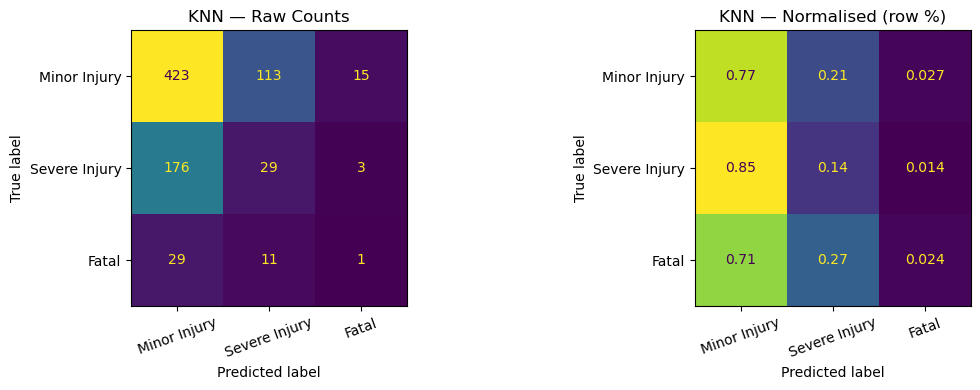

In [29]:
# KNN — uses SCALED data
# Hyperparameters:
#   n_neighbors : too few = overfit, too many = over-smoothed boundary
#   weights     : 'distance' gives closer neighbours more vote weight
#   metric      : euclidean vs manhattan distance function

knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(np.ascontiguousarray(X_train_scaled), y_train)

print("Best KNN params :", knn_grid.best_params_)
print("Best CV F1      :", round(knn_grid.best_score_, 4))

results.append(evaluate_model(
    "KNN",
    knn_grid.best_estimator_,
    np.ascontiguousarray(X_train_scaled),
    np.ascontiguousarray(X_test_scaled),
    y_train, y_test
))

**KNN Results**
KNN is a lazy, non-parametric learner that classifies each point by majority
vote among its k nearest neighbours in feature space. It requires no training
phase but is sensitive to feature scale (hence StandardScaler) and class
imbalance.

With Fatal cases making up only 5% of the data, KNN neighbourhoods are
dominated by Minor Injury points, making it hard to identify Fatal crashes.
'distance' weighting partially mitigates this. Check the normalised confusion
matrix row for Fatal — low recall there confirms the imbalance effect.

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best DT params : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1     : 0.3427

  Decision Tree
  Accuracy        : 0.5375
  Weighted F1     : 0.5411   |   Macro F1 : 0.3200
  Weighted Prec   : 0.5449   |   Weighted Recall : 0.5375

               precision    recall  f1-score   support

 Minor Injury       0.69      0.69      0.69       551
Severe Injury       0.25      0.25      0.25       208
        Fatal       0.02      0.02      0.02        41

     accuracy                           0.54       800
    macro avg       0.32      0.32      0.32       800
 weighted avg       0.54      0.54      0.54       800



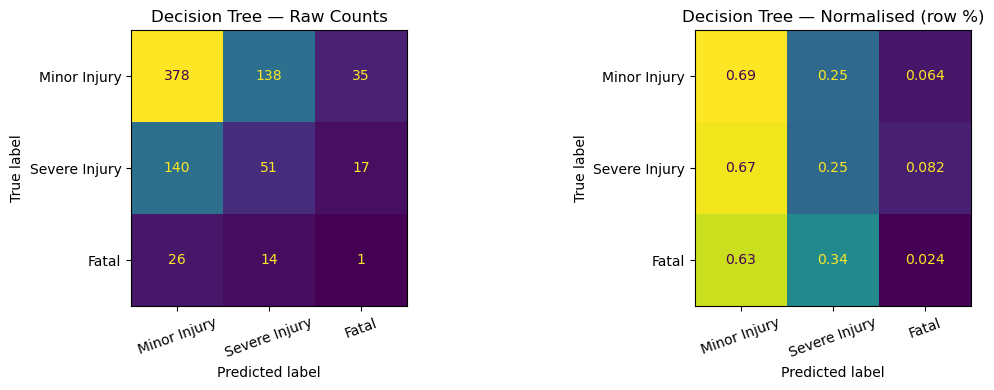

In [30]:
# DECISION TREE — uses UNSCALED data
# Scale-invariant: splits on feature thresholds, not distances.
# Hyperparameters:
#   max_depth         : caps tree depth to prevent memorising training data
#   min_samples_split : minimum samples required to make a split
#   min_samples_leaf  : minimum points at a leaf → smoother, less overfit
#   criterion         : gini (impurity) vs entropy (information gain)
#   class_weight      : 'balanced' upweights Fatal/Severe during training

dt_params = {
    'max_depth':         [3, 5, 8, 12, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf':  [1, 5, 10],
    'criterion':         ['gini', 'entropy'],
    'class_weight':      [None, 'balanced'],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print("Best DT params :", dt_grid.best_params_)
print("Best CV F1     :", round(dt_grid.best_score_, 4))

results.append(evaluate_model(
    "Decision Tree",
    dt_grid.best_estimator_,
    X_train, X_test,
    y_train, y_test
))

**Decision Tree Results**

Decision Trees recursively partition feature space by finding the split on
each feature that maximally reduces impurity. Every prediction can be traced
as a path of if/else rules, fully interpretable.

A shallow tree collapses most predictions to "Minor Injury" (good accuracy on
the majority class, terrible recall on Fatal/Severe). A deeper tree with
class_weight='balanced' shifts weight toward minority classes. GridSearch
resolves the tension between depth and generalisation.

Key weakness: high variance. A single tree is sensitive to the exact training
sample. Random Forest directly addresses this by averaging over many trees.

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best RF params : {'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV F1     : 0.3298

  Random Forest
  Accuracy        : 0.5088
  Weighted F1     : 0.5329   |   Macro F1 : 0.3254
  Weighted Prec   : 0.5617   |   Weighted Recall : 0.5088

               precision    recall  f1-score   support

 Minor Injury       0.71      0.62      0.66       551
Severe Injury       0.29      0.32      0.30       208
        Fatal       0.01      0.02      0.02        41

     accuracy                           0.51       800
    macro avg       0.34      0.32      0.33       800
 weighted avg       0.56      0.51      0.53       800



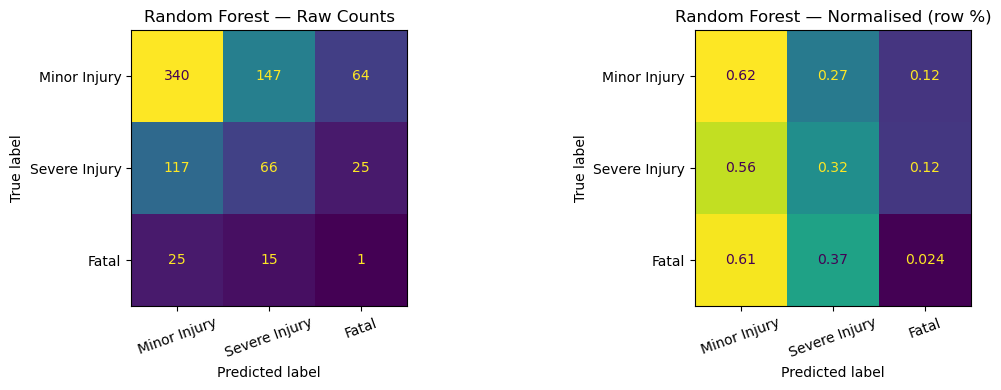

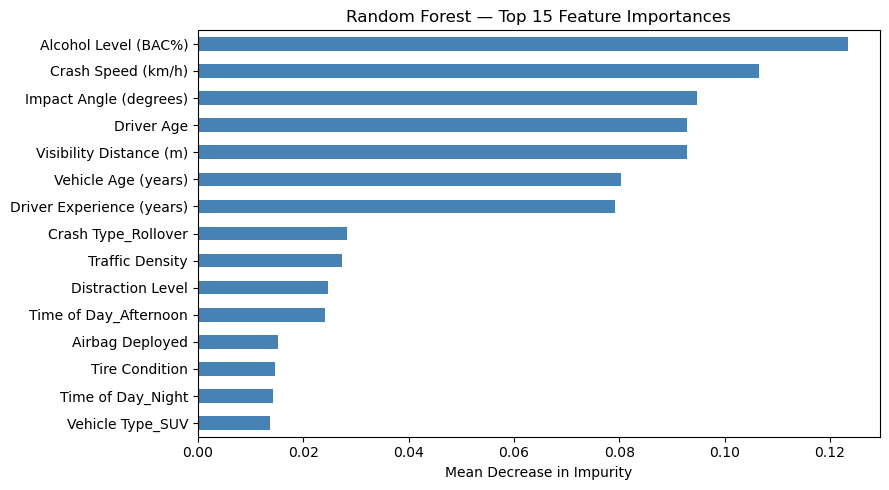

In [32]:
# RANDOM FOREST — uses UNSCALED data
# Ensemble of N decision trees, each on a bootstrap sample + random feature subset.
# Final prediction = majority vote. Reduces the high variance of single trees.
# Hyperparameters:
#   n_estimators        : more trees = more stable but slower
#   max_depth           : per-tree depth cap
#   min_samples_leaf    : minimum leaf size
#   max_features        : 'sqrt' = standard for classification
#   class_weight        : 'balanced_subsample' reweights within each bootstrap

rf_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features':     ['sqrt', 'log2'],
    'class_weight':     [None, 'balanced_subsample'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print("Best RF params :", rf_grid.best_params_)
print("Best CV F1     :", round(rf_grid.best_score_, 4))

results.append(evaluate_model(
    "Random Forest",
    rf_grid.best_estimator_,
    X_train, X_test,
    y_train, y_test
))

# Feature importance plot
importances = pd.Series(
    rf_grid.best_estimator_.feature_importances_, index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

**Random Forest Results**

Random Forest is typically the strongest performer in tabular classification tasks.
By combining hundreds of decorrelated trees — each seeing a random feature subset
at each split, it achieves low bias and low variance simultaneously.

The feature importance plot reveals which variables most drive severity predictions.
Crash Speed, Alcohol Level (BAC%), and Visibility Distance are expected to rank
highly given their direct physical relationship to crash outcome.

'balanced_subsample' reweights class contributions within each bootstrap sample
independently, which is stronger than global 'balanced' for imbalanced datasets
because the weighting is recalculated per tree rather than once globally.

If RF significantly outperforms Logistic Regression, this confirms the decision
boundary between severity classes is non-linear and interaction-driven, precisely
what ensemble trees are designed to capture.

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/salmaelafifi/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/salmaelafifi/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/salmaelafifi/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/salmaelafifi/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/salmaelafifi/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/salmaelafifi/anaconda3/

Best LR params : {'C': 10, 'class_weight': 'balanced', 'max_iter': 5000, 'penalty': 'l1', 'solver': 'saga', 'tol': 0.001}
Best CV F1     : 0.2804

  Logistic Regression
  Accuracy        : 0.3300
  Weighted F1     : 0.3808   |   Macro F1 : 0.2669
  Weighted Prec   : 0.5399   |   Weighted Recall : 0.3300

               precision    recall  f1-score   support

 Minor Injury       0.68      0.31      0.43       551
Severe Injury       0.26      0.41      0.32       208
        Fatal       0.03      0.17      0.05        41

     accuracy                           0.33       800
    macro avg       0.33      0.30      0.27       800
 weighted avg       0.54      0.33      0.38       800



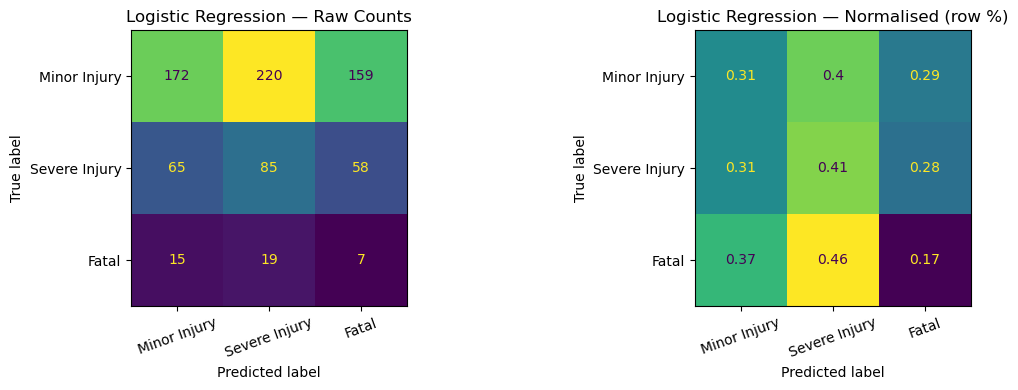

In [33]:
# LOGISTIC REGRESSION — uses SCALED data
# Linear probabilistic classifier using softmax for multi-class output.
# Serves as the linear baseline to compare against non-linear models.
# Hyperparameters:
#   C             : inverse regularisation — smaller C = stronger penalty
#   penalty       : l2 (Ridge, shrinks all weights) vs l1 (Lasso, zeros some out)
#   solver        : lbfgs for l2 multi-class; saga required for l1
#   class_weight  : handles class imbalance

lr_params = [
    {
        'C':            [0.01, 0.1, 1, 10, 100],
        'penalty':      ['l2'],
        'solver':       ['lbfgs'],
        'class_weight': [None, 'balanced'],
        'max_iter':     [3000],
        'tol':          [1e-4],
    },
    {
        'C':            [0.01, 0.1, 1, 10, 100],
        'penalty':      ['l1'],
        'solver':       ['saga'],
        'class_weight': [None, 'balanced'],
        'max_iter':     [5000],
        'tol':          [1e-3],
    },
]

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='multinomial'),
    lr_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_scaled, y_train)

print("Best LR params :", lr_grid.best_params_)
print("Best CV F1     :", round(lr_grid.best_score_, 4))

results.append(evaluate_model(
    "Logistic Regression",
    lr_grid.best_estimator_,
    X_train_scaled, X_test_scaled,
    y_train, y_test
))

**Logistic Regression Results**

Logistic Regression models the log-odds of each class as a linear combination of
features, producing calibrated probabilities via softmax for the 3 severity classes.

It is our linear baseline. If non-linear models (RF, DT, KNN) substantially
outperform it, the severity classes are NOT linearly separable,interactions and
non-linearities exist that a linear boundary cannot capture.

L1 regularisation (Lasso) is particularly informative: it drives some feature
coefficients exactly to zero, performing implicit feature selection. If L1 is
chosen by GridSearch, the non-zero coefficients are the features the model finds
most discriminative.

Expected weakness: LR will likely handle Minor vs Severe reasonably but struggle
with Fatal cases, too few training examples and no non-linear mechanism to
separate this rare but extreme class from the rest.

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best NB params : {'var_smoothing': 1e-11}
Best CV F1     : 0.3088

  Naïve Bayes
  Accuracy        : 0.6200
  Weighted F1     : 0.5511   |   Macro F1 : 0.3018
  Weighted Prec   : 0.5179   |   Weighted Recall : 0.6200

               precision    recall  f1-score   support

 Minor Injury       0.68      0.88      0.76       551
Severe Injury       0.18      0.05      0.08       208
        Fatal       0.07      0.05      0.06        41

     accuracy                           0.62       800
    macro avg       0.31      0.33      0.30       800
 weighted avg       0.52      0.62      0.55       800



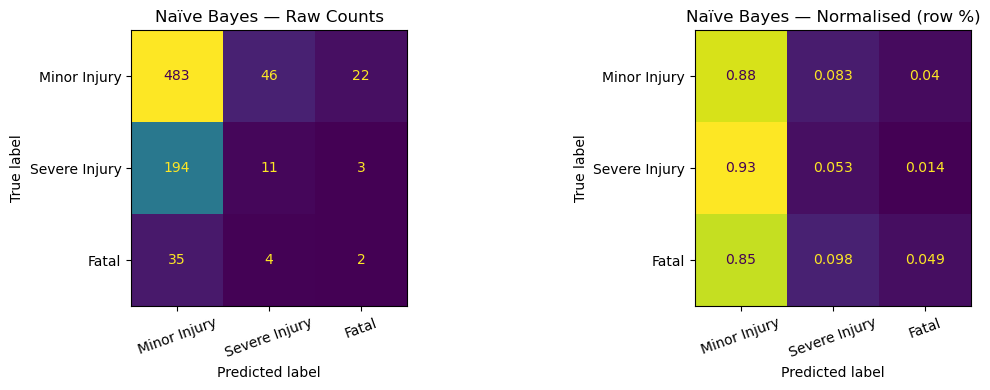

In [34]:
# GAUSSIAN NAÏVE BAYES — uses SCALED data
# Probabilistic classifier based on Bayes' theorem with conditional independence
# assumption between features. Fast probabilistic baseline.
# Hyperparameters:
#   var_smoothing : adds a fraction of the largest variance to all feature
#                  variances — prevents zero-probability issues

nb_params = {
    'var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1],
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
nb_grid.fit(X_train_scaled, y_train)

print("Best NB params :", nb_grid.best_params_)
print("Best CV F1     :", round(nb_grid.best_score_, 4))

results.append(evaluate_model(
    "Naïve Bayes",
    nb_grid.best_estimator_,
    X_train_scaled, X_test_scaled,
    y_train, y_test
))

**Naïve Bayes Results**

GaussianNB models each feature as a Gaussian (normal) distribution within each
class and computes posterior probabilities via Bayes' theorem.

The core assumption, feature independence given class, is clearly violated here.
Crash Speed and Crash Type are correlated; Alcohol Level and Distraction Level
co-occur. This violation is why NB typically underperforms richer models on
structured tabular data.

However, NB has a natural mechanism for handling class imbalance: prior probabilities
are directly estimated from class frequencies in training, so the rare Fatal class
is not completely ignored as it might be in a cost-unweighted linear model.

NB is valuable as a fast baseline and for understanding which class distributions
overlap most. The confusion matrix will likely show Severe Injury being the most
confused class since its Gaussian distributions for key features overlap with both
Minor and Fatal.

**4. Results and Comparisons**

In [36]:
results_df = pd.DataFrame(results).set_index('Model')

# Highlight the best value in each column
styled = results_df.style \
    .highlight_max(axis=0, color='green') \
    .format(precision=4)

print(results_df.to_string())
styled

                     Accuracy  Weighted F1  Macro F1  Precision (W)  Recall (W)
Model                                                                          
KNN                    0.5662       0.5377    0.3039         0.5159      0.5662
Decision Tree          0.5375       0.5411    0.3200         0.5449      0.5375
Random Forest          0.5088       0.5329    0.3254         0.5617      0.5088
Logistic Regression    0.3300       0.3808    0.2669         0.5399      0.3300
Naïve Bayes            0.6200       0.5511    0.3018         0.5179      0.6200


,Accuracy,Weighted F1,Macro F1,Precision (W),Recall (W)
Model,,,,,
KNN,0.5662,0.5377,0.3039,0.5159,0.5662
Decision Tree,0.5375,0.5411,0.3200,0.5449,0.5375
Random Forest,0.5088,0.5329,0.3254,0.5617,0.5088
Logistic Regression,0.3300,0.3808,0.2669,0.5399,0.3300
Naïve Bayes,0.6200,0.5511,0.3018,0.5179,0.6200


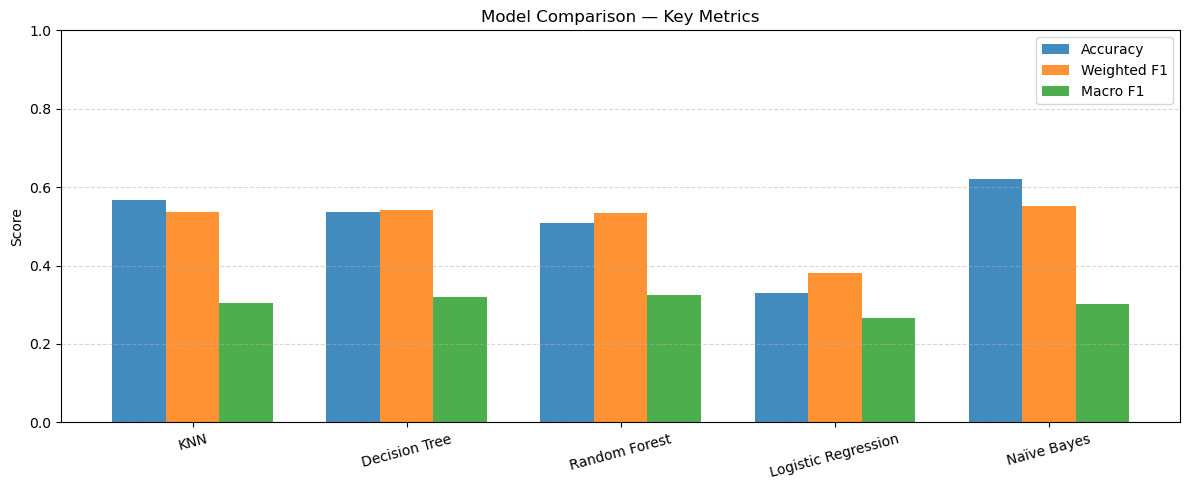

In [37]:
metrics = ['Accuracy', 'Weighted F1', 'Macro F1']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Key Metrics')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Best model by Macro F1: Random Forest

  BEST MODEL: Random Forest
               precision    recall  f1-score   support

 Minor Injury       0.71      0.62      0.66       551
Severe Injury       0.29      0.32      0.30       208
        Fatal       0.01      0.02      0.02        41

     accuracy                           0.51       800
    macro avg       0.34      0.32      0.33       800
 weighted avg       0.56      0.51      0.53       800



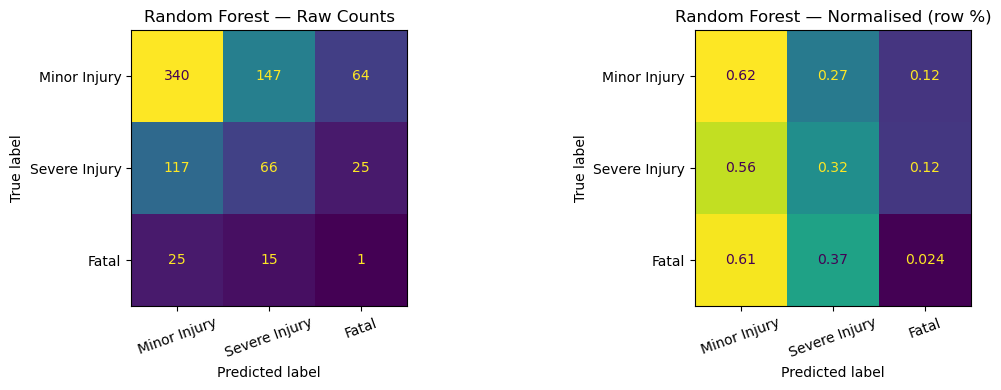

In [38]:
# Identify the best model by Macro F1 (most informative for imbalanced multi-class)
best_model_name = results_df['Macro F1'].idxmax()
print(f"Best model by Macro F1: {best_model_name}")

# Retrieve the best estimator
model_lookup = {
    'KNN':                 knn_grid.best_estimator_,
    'Decision Tree':       dt_grid.best_estimator_,
    'Random Forest':       rf_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
    'Naïve Bayes':         nb_grid.best_estimator_,
}

# Scaled models need X_test_scaled; tree models need X_test
scaled_models = {'KNN', 'Logistic Regression', 'Naïve Bayes'}
if best_model_name in scaled_models:
    X_tr_best, X_te_best = X_train_scaled, X_test_scaled
else:
    X_tr_best, X_te_best = X_train, X_test

best_model = model_lookup[best_model_name]
y_pred_best = best_model.predict(X_te_best)

print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_best,
                             target_names=['Minor Injury', 'Severe Injury', 'Fatal']))

# Per-class breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
label_names = ['Minor Injury', 'Severe Injury', 'Fatal']
ConfusionMatrixDisplay(cm,      display_labels=label_names).plot(ax=axes[0], colorbar=False)
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(ax=axes[1], colorbar=False)
axes[0].set_title(f"{best_model_name} — Raw Counts")
axes[1].set_title(f"{best_model_name} — Normalised (row %)")
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

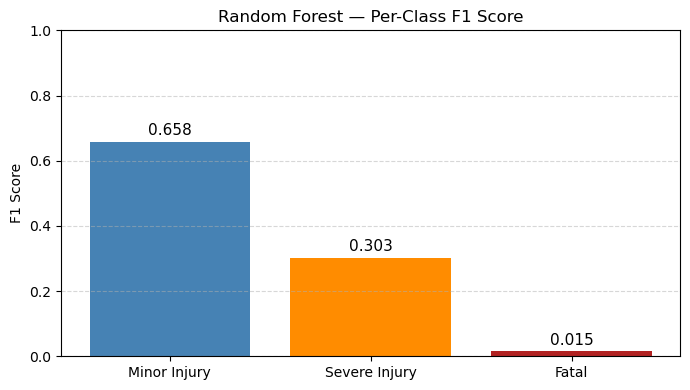

In [39]:
from sklearn.metrics import f1_score

class_f1 = f1_score(y_test, y_pred_best, average=None)
class_labels = ['Minor Injury', 'Severe Injury', 'Fatal']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_labels, class_f1, color=['steelblue', 'darkorange', 'firebrick'])
ax.set_ylim(0, 1)
ax.set_ylabel('F1 Score')
ax.set_title(f'{best_model_name} — Per-Class F1 Score')
for bar, val in zip(bars, class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha='center', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**5. Testing on Best Performing Model**

In [41]:
import pandas as pd
import numpy as np

# ── Step 1: Load the test CSV and create an unlabeled copy ───────────────────
df_test_full = pd.read_csv('car-crash-severity-prediction/car_crash_test.csv')

# Save a copy without the label column
df_test_full.drop(columns='Severity').to_csv('car_crash_test_no_labels.csv', index=False)
print("Saved: car_crash_test_no_labels.csv")

# Keep actual labels for comparison later
y_actual = df_test_full['Severity'].map({'Minor Injury': 0, 'Severe Injury': 1, 'Fatal': 2})

Saved: car_crash_test_no_labels.csv


In [42]:
# ── Step 2: Load the unlabeled CSV and apply the same preprocessing ──────────
X_new = pd.read_csv('car_crash_test_no_labels.csv')

# Distraction Level: MNAR → fill with 'None'
X_new['Distraction Level'] = X_new['Distraction Level'].fillna('None')

# Binary encoding
binary_maps = {
    'Airbag Deployed': {'Yes': 1, 'No': 0},
    'Seatbelt Used':   {'Yes': 1, 'No': 0},
    'Brake Condition': {'Good': 1, 'Worn out': 0},
    'Tire Condition':  {'Good': 1, 'Worn out': 0},
}
for col, mapping in binary_maps.items():
    X_new[col] = X_new[col].map(mapping)

# Ordinal encoding — use the same fitted encoders from training
for col, enc in fitted_ordinal_encoders.items():
    X_new[col] = enc.transform(X_new[[col]])

# One-hot encoding — align columns to training set
nominal_cols = ['Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Time of Day']
X_new = pd.get_dummies(X_new, columns=nominal_cols, drop_first=False, dtype=int)
X_new = X_new.reindex(columns=train_feature_cols, fill_value=0)

print("Preprocessing complete. Shape:", X_new.shape)

Preprocessing complete. Shape: (1000, 32)


In [43]:
# ── Step 3: Predict using Random Forest ─────────────────────────────────────
y_pred = rf_grid.best_estimator_.predict(X_new)
print("Predictions generated using: Random Forest")

Predictions generated using: Random Forest


In [44]:
# ── Step 4: Compare predictions vs actual labels ─────────────────────────────
label_map = {0: 'Minor Injury', 1: 'Severe Injury', 2: 'Fatal'}

comparison_df = pd.DataFrame({
    'Actual':    y_actual.map(label_map).values,
    'Predicted': pd.Series(y_pred).map(label_map).values,
    'Correct':   (y_actual.values == y_pred)
})
comparison_df.index.name = 'Sample'

comparison_df.to_csv('prediction_comparison.csv', index=True)

print(f"Total samples : {len(comparison_df)}")
print(f"Correct       : {comparison_df['Correct'].sum()}")
print(f"Wrong         : {(~comparison_df['Correct']).sum()}")
print(f"\nFirst 10 rows:")
comparison_df.head(10)

Total samples : 1000
Correct       : 516
Wrong         : 484

First 10 rows:


,Actual,Predicted,Correct
Sample,,,
0,Minor Injury,Severe Injury,False
1,Minor Injury,Minor Injury,True
2,Minor Injury,Fatal,False
3,Severe Injury,Minor Injury,False
4,Minor Injury,Minor Injury,True
5,Minor Injury,Severe Injury,False
6,Minor Injury,Minor Injury,True
7,Severe Injury,Severe Injury,True
8,Severe Injury,Fatal,False


Accuracy    : 0.5160
Weighted F1 : 0.5396
Macro F1    : 0.3306

               precision    recall  f1-score   support

 Minor Injury       0.71      0.63      0.67       710
Severe Injury       0.24      0.27      0.25       249
        Fatal       0.05      0.12      0.07        41

     accuracy                           0.52      1000
    macro avg       0.33      0.34      0.33      1000
 weighted avg       0.57      0.52      0.54      1000



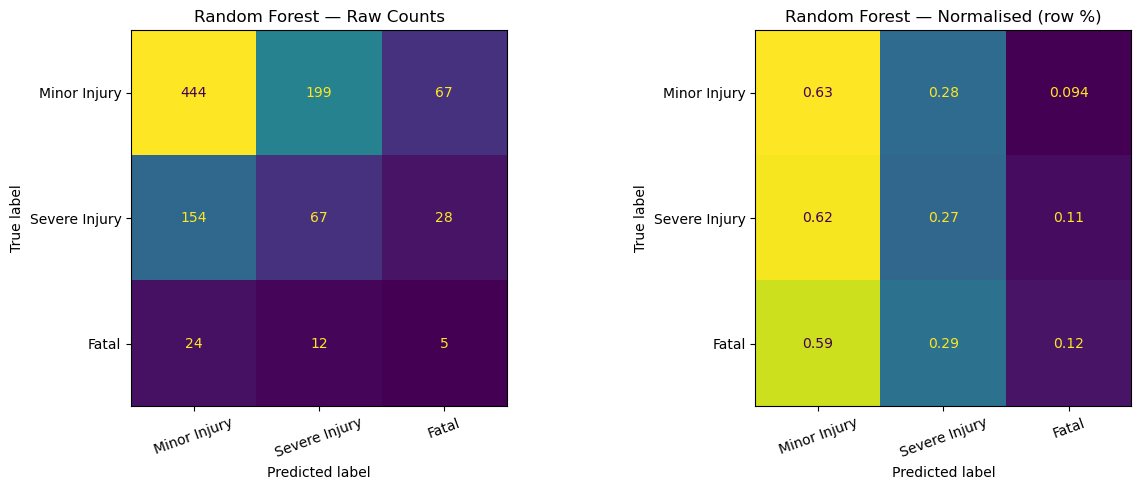

In [45]:
# ── Step 5: Full evaluation report ───────────────────────────────────────────
label_names = ['Minor Injury', 'Severe Injury', 'Fatal']

print(f"Accuracy    : {accuracy_score(y_actual, y_pred):.4f}")
print(f"Weighted F1 : {f1_score(y_actual, y_pred, average='weighted'):.4f}")
print(f"Macro F1    : {f1_score(y_actual, y_pred, average='macro'):.4f}")
print(f"\n{classification_report(y_actual, y_pred, target_names=label_names)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm      = confusion_matrix(y_actual, y_pred)
cm_norm = confusion_matrix(y_actual, y_pred, normalize='true')
ConfusionMatrixDisplay(cm,      display_labels=label_names).plot(ax=axes[0], colorbar=False)
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(ax=axes[1], colorbar=False)
axes[0].set_title("Random Forest — Raw Counts")
axes[1].set_title("Random Forest — Normalised (row %)")
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [46]:
# ── Step 6: Misclassification breakdown ──────────────────────────────────────
wrong = comparison_df[~comparison_df['Correct']]

print(f"Misclassified: {len(wrong)} / {len(comparison_df)}\n")
print("Confusion breakdown (Actual → Predicted):")
print(wrong.groupby(['Actual', 'Predicted']).size().rename('Count').to_string())

Misclassified: 484 / 1000

Confusion breakdown (Actual → Predicted):
Actual         Predicted    
Fatal          Minor Injury      24
               Severe Injury     12
Minor Injury   Fatal             67
               Severe Injury    199
Severe Injury  Fatal             28
               Minor Injury     154
